<a href="https://colab.research.google.com/github/Nois12/AIFFEL_quest_rs/blob/main/Exploration/Ex06/Text_Sentiment_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mkdir -p ~/work/sentiment_classification
!pip install gensim==4.3.2
!pip install scipy==1.12.0 numpy==1.26.3
!pip install gdown


데이터셋 다운로드

In [ ]:
!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
!mkdir -p ~/work/sentiment_classification/data
!mv ratings_*.txt ~/work/sentiment_classification/data

--2026-08-11 08:37:56--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14628807 (14M) [text/plain]
Saving to: ‘ratings_train.txt’

ratings_train.txt   100%[===================>]  13.95M  --.-KB/s    in 0.09s   

2026-08-11 08:37:56 (152 MB/s) - ‘ratings_train.txt’ saved [14628807/14628807]

--2026-08-11 08:37:56--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4893335 (4.7M) [application/octet-

한국어 형태소 분석기 설치

In [ ]:
!pip install konlpy
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
%cd Mecab-ko-for-Google-Colab/
!bash install_mecab-ko_on_colab_light_220429.sh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 36.0 MB/s eta 0:00:00
Cloning into 'Mecab-ko-for-Google-Colab'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 138 (delta 26), reused 22 (delta 8), pack-reused 91 (from 1)
Receiving objects: 100% (138/138), 1.72 MiB | 4.53 MiB/s, done.
Resolving deltas: 100% (65/65), done.
/content/Mecab-ko-for-Google-Colab
Installing konlpy.....
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2026-08-11 08:38:12--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 104.192.142.25, 104.192.142.24, 104.192.142.26, ...
Connecting to bitbucket.org (bitbucket.org)|104.192.142.25|:443... connected.
HTTP request sent, a

파이썬 버전 확인

In [ ]:
!python --version

Python 3.12.13


In [ ]:
!pip install python-mecab-ko

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 579.6/579.6 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 37.6 MB/s eta 0:00:00


라이브러리 불러오기

In [ ]:
import pandas
import konlpy
import gensim

import pandas as pd
import os

import numpy as np
import torch
import matplotlib.pyplot as plt
import urllib.request
import subprocess
import gensim.downloader as api

import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from gensim.models.keyedvectors import Word2VecKeyedVectors
from konlpy.tag import Mecab
from collections import Counter
from gensim.models import KeyedVectors, Word2Vec

print(pandas.__version__)
print(konlpy.__version__)
print(gensim.__version__)

2.2.2
0.6.0
4.3.2


학습 및 테스트 데이터 불러오기

In [ ]:
train_path = os.getenv("HOME") + '/work/sentiment_classification/data/ratings_train.txt'
test_path = os.getenv("HOME") + '/work/sentiment_classification/data/ratings_test.txt'

train_data = pd.read_table(train_path)
test_data = pd.read_table(test_path)

train_data.head()

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


데이터 전처리 및 인코딩

In [ ]:
tokenizer = Mecab()
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

def load_data(train_data, test_data, num_words=10000):
    train_data.drop_duplicates(subset=['document'], inplace=True)
    train_data = train_data.dropna(how = 'any')
    test_data.drop_duplicates(subset=['document'], inplace=True)
    test_data = test_data.dropna(how = 'any')

    X_train = []
    for sentence in train_data['document']:
        temp_X = tokenizer.morphs(sentence) # 토큰화
        temp_X = [word for word in temp_X if not word in stopwords] # 불용어 제거
        X_train.append(temp_X)

    X_test = []
    for sentence in test_data['document']:
        temp_X = tokenizer.morphs(sentence) # 토큰화
        temp_X = [word for word in temp_X if not word in stopwords] # 불용어 제거
        X_test.append(temp_X)

    words = np.concatenate(X_train).tolist()
    counter = Counter(words)
    counter = counter.most_common(num_words-4)
    vocab = ['<PAD>', '<BOS>', '<UNK>', '<UNUSED>'] + [key for key, _ in counter]
    word_to_index = {word:index for index, word in enumerate(vocab)}

    def wordlist_to_indexlist(wordlist):
        return [word_to_index[word] if word in word_to_index else word_to_index['<UNK>'] for word in wordlist]

    X_train = list(map(wordlist_to_indexlist, X_train))
    X_test = list(map(wordlist_to_indexlist, X_test))

    return X_train, np.array(list(train_data['label'])), X_test, np.array(list(test_data['label'])), word_to_index

X_train, y_train, X_test, y_test, word_to_index = load_data(train_data, test_data)


In [ ]:
index_to_word = {index:word for word, index in word_to_index.items()}

문장 Encode/Decode 함수 정의

In [ ]:
# 문장 1개를 활용할 딕셔너리와 함께 주면, 단어 인덱스 리스트 벡터로 변환해 주는 함수
def get_encoded_sentence(sentence, word_to_index):
    return [word_to_index['<BOS>']]+[word_to_index[word] if word in word_to_index else word_to_index['<UNK>'] for word in sentence.split()]

# 여러 개의 문장 리스트를 한꺼번에 단어 인덱스 리스트 벡터로 encode해 주는 함수
def get_encoded_sentences(sentences, word_to_index):
    return [get_encoded_sentence(sentence, word_to_index) for sentence in sentences]

# 숫자 벡터로 encode된 문장을 원래대로 decode하는 함수
def get_decoded_sentence(encoded_sentence, index_to_word):
    return ' '.join(index_to_word[index] if index in index_to_word else '<UNK>' for index in encoded_sentence[1:])  #[1:]를 통해 <BOS>를 제외

# 여러 개의 숫자 벡터로 encode된 문장을 한꺼번에 원래대로 decode하는 함수
def get_decoded_sentences(encoded_sentences, index_to_word):
    return [get_decoded_sentence(encoded_sentence, index_to_word) for encoded_sentence in encoded_sentences]

데이터 분석 및 패딩 (torch.tensor 변환)

In [ ]:
# 1. 문장 길이 분석
total_data_text = list(X_train) + list(X_test)
num_tokens = [len(tokens) for tokens in total_data_text]
num_tokens = np.array(num_tokens)

print('문장길이 평균 : ', np.mean(num_tokens))
print('문장길이 최대 : ', np.max(num_tokens))
print('문장길이 표준편차 : ', np.std(num_tokens))

# 2. 적절한 maxlen 설정 (평균 + 2*표준편차)
max_tokens = np.mean(num_tokens) + 2 * np.std(num_tokens)
maxlen = int(max_tokens)
print('pad_sequences maxlen : ', maxlen)
print(f'전체 문장의 {np.sum(num_tokens < max_tokens) / len(num_tokens) * 100:.2f}%가 maxlen 이내입니다.')

# 3. 예제 코드 방식의 pad_sequences 함수
def pad_sequences(data, maxlen):
    padded_data = []
    for sentence in data:
        if len(sentence) < maxlen:
            sentence = sentence + [0] * (maxlen - len(sentence))
        else:
            sentence = sentence[:maxlen]
        padded_data.append(sentence)
    return np.array(padded_data)

x_train_padded = pad_sequences(X_train, maxlen)
x_test_padded = pad_sequences(X_test, maxlen)

x_train_tensor = torch.tensor(x_train_padded, dtype=torch.long)
x_test_tensor = torch.tensor(x_test_padded, dtype=torch.long)

print("패딩 완료 후 Train Tensor Shape:", x_train_tensor.shape)

문장길이 평균 :  15.971004254142798
문장길이 최대 :  116
문장길이 표준편차 :  12.844081305622485
pad_sequences maxlen :  41
전체 문장의 93.43%가 maxlen 이내입니다.
패딩 완료 후 Train Tensor Shape: torch.Size([146182, 41])


Validation set 분리 및 DataLoader 구축

In [ ]:
x_val_tensor = x_train_tensor[:10000]
y_val = y_train[:10000]
y_val_tensor = torch.tensor(y_val, dtype=torch.float)

partial_x_train_tensor = x_train_tensor[10000:]
partial_y_train = y_train[10000:]
partial_y_train_tensor = torch.tensor(partial_y_train, dtype=torch.float)

train_dataset = TensorDataset(partial_x_train_tensor, partial_y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

x_test_tensor = torch.tensor(x_test_padded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)


3가지 모델 구성 및 학습

In [ ]:
vocab_size = 10000
word_vector_dim = 16

# [모델 1] LSTM
class Model_1(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super(Model_1, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.lstm = nn.LSTM(word_vector_dim, 8, batch_first=True)
        self.fc1 = nn.Linear(8, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        lstm_out, (h_n, c_n) = self.lstm(x)
        x = h_n[-1]
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

# [모델 2] 1D-CNN
class Model_2(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super(Model_2, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.conv1 = nn.Conv1d(word_vector_dim, 16, kernel_size=7)
        self.conv2 = nn.Conv1d(16, 16, kernel_size=7)
        self.pool = nn.MaxPool1d(5)
        self.global_max_pooling = nn.AdaptiveMaxPool1d(1)
        self.fc1 = nn.Linear(16, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.global_max_pooling(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

# [모델 3] Global Max Pooling 1D
class Model_3(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super(Model_3, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.global_max_pooling = nn.AdaptiveMaxPool1d(1)
        self.fc1 = nn.Linear(word_vector_dim, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.global_max_pooling(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

# 공통 학습 루프 함수
def train_model(model, epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    optimizer = optim.Adam(model.parameters())
    loss_fn = nn.BCELoss()

    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs.squeeze(), labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            predicted = (outputs.squeeze() > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_losses.append(running_loss / len(train_loader))
        train_accs.append(correct / total)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = loss_fn(outputs.squeeze(), labels)
                val_loss += loss.item()
                predicted = (outputs.squeeze() > 0.5).float()
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_losses.append(val_loss / len(val_loader))
        val_accs.append(val_correct / val_total)

        print(f"[{model.__class__.__name__}] Epoch {epoch+1:02d}/{epochs} - "
              f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.4f} | "
              f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accs[-1]:.4f}")

    return train_losses, val_losses, train_accs, val_accs

results = {}

print("=== Model_1 (LSTM) 학습 시작 ===")
model_1 = Model_1(vocab_size, word_vector_dim)
results['Model_1 (LSTM)'] = train_model(model_1, epochs=10)

print("\n=== Model_2 (1D-CNN) 학습 시작 ===")
model_2 = Model_2(vocab_size, word_vector_dim)
results['Model_2 (1D-CNN)'] = train_model(model_2, epochs=10)

print("\n=== Model_3 (Global Max Pooling) 학습 시작 ===")
model_3 = Model_3(vocab_size, word_vector_dim)
results['Model_3 (GlobalMaxPool)'] = train_model(model_3, epochs=10)

train_losses, val_losses, train_accs, val_accs = results['Model_1 (LSTM)']


=== Model_1 (LSTM) 학습 시작 ===
[Model_1] Epoch 01/10 - Train Loss: 0.6929, Train Acc: 0.5033 | Val Loss: 0.6924, Val Acc: 0.5084
[Model_1] Epoch 02/10 - Train Loss: 0.6915, Train Acc: 0.5110 | Val Loss: 0.6733, Val Acc: 0.5926
[Model_1] Epoch 03/10 - Train Loss: 0.6121, Train Acc: 0.6716 | Val Loss: 0.5631, Val Acc: 0.7179
[Model_1] Epoch 04/10 - Train Loss: 0.5180, Train Acc: 0.7518 | Val Loss: 0.4879, Val Acc: 0.7697
[Model_1] Epoch 05/10 - Train Loss: 0.4519, Train Acc: 0.7947 | Val Loss: 0.4390, Val Acc: 0.7994
[Model_1] Epoch 06/10 - Train Loss: 0.4083, Train Acc: 0.8200 | Val Loss: 0.4099, Val Acc: 0.8149
[Model_1] Epoch 07/10 - Train Loss: 0.3810, Train Acc: 0.8352 | Val Loss: 0.3904, Val Acc: 0.8270
[Model_1] Epoch 08/10 - Train Loss: 0.3621, Train Acc: 0.8449 | Val Loss: 0.3842, Val Acc: 0.8321
[Model_1] Epoch 09/10 - Train Loss: 0.3474, Train Acc: 0.8531 | Val Loss: 0.3708, Val Acc: 0.8374
[Model_1] Epoch 10/10 - Train Loss: 0.3358, Train Acc: 0.8594 | Val Loss: 0.3657, Val Acc

Loss, Accuracy 그래프 시각화

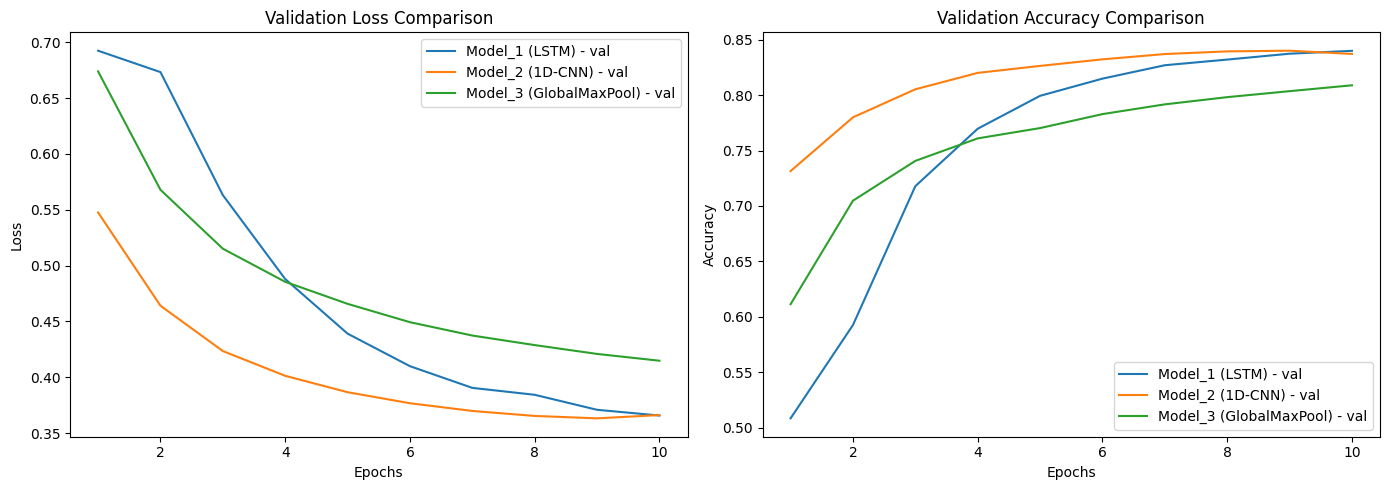

Model_1 (LSTM): 최종 Val Loss=0.3657, 최종 Val Acc=0.8400
Model_2 (1D-CNN): 최종 Val Loss=0.3661, 최종 Val Acc=0.8372
Model_3 (GlobalMaxPool): 최종 Val Loss=0.4148, 최종 Val Acc=0.8089


In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for name, (tl, vl, ta, va) in results.items():
    epochs_range = range(1, len(tl) + 1)
    plt.plot(epochs_range, vl, label=f'{name} - val')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
for name, (tl, vl, ta, va) in results.items():
    epochs_range = range(1, len(ta) + 1)
    plt.plot(epochs_range, va, label=f'{name} - val')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

for name, (tl, vl, ta, va) in results.items():
    print(f"{name}: 최종 Val Loss={vl[-1]:.4f}, 최종 Val Acc={va[-1]:.4f}")


자체 학습된 Embedding 레이어 분석

In [ ]:
# 자체 학습된 임베딩(Model_1) 레이어 분석
os.makedirs(os.path.expanduser('~') + '/work/sentiment_classification/word2vec_emb', exist_ok=True)
self_trained_w2v_path = os.path.expanduser('~') + '/work/sentiment_classification/word2vec_emb/word2vec.txt'

index_to_word = {index: word for word, index in word_to_index.items()}

# 가중치 파일로 쓰기 (특수토큰 4개는 제외)
with open(self_trained_w2v_path, 'w', encoding='utf-8') as f:
    f.write('{} {}\n'.format(vocab_size - 4, word_vector_dim))
    vectors = model_1.embedding.weight.detach().cpu().numpy()
    for i in range(4, vocab_size):
        f.write('{} {}\n'.format(index_to_word[i], ' '.join(map(str, vectors[i, :]))))

# Gensim 로드 후 유사 단어 테스트
self_trained_wv = Word2VecKeyedVectors.load_word2vec_format(self_trained_w2v_path, binary=False)

print("자체 학습 임베딩 '영화' 유사단어:")
print(self_trained_wv.similar_by_word("영화"))


자체 학습 임베딩 '영화' 유사단어:
[('나오미', 0.7713965177536011), ('중견', 0.756894588470459), ('에릭', 0.7565170526504517), ('필수', 0.7537204623222351), ('지상주의', 0.736409604549408), ('볼륨', 0.7281721234321594), ('몸부림', 0.7197511792182922), ('고자', 0.7159510254859924), ('무자비', 0.7100810408592224), ('이라도', 0.7085172533988953)]


### Gensim을 활용한 자체학습 임베딩과 사전학습 Word2Vec 비교


In [ ]:
# 1. 자체학습 임베딩 준비

self_trained_w2v_path = os.path.expanduser(
    '~/work/sentiment_classification/word2vec_emb/word2vec.txt'
)

self_trained_wv = KeyedVectors.load_word2vec_format(
    self_trained_w2v_path,
    binary=False
)

# 영화와 유사한 단어 확인
print("=" * 60)
print("[자체학습 임베딩] '영화' 유사 단어")
print("=" * 60)

self_similar = self_trained_wv.most_similar('영화', topn=10)

for word, score in self_similar:
    print(f"{word:10s} : {score:.4f}")


# 2. 사전학습 한국어 Word2Vec 준비

import pickle
from io import BytesIO

ko_zip_path = './ko.zip'
ko_bin_path = './ko.bin'
converted_path = './ko_w2v_format.bin'

if not os.path.exists(ko_bin_path):
    print("\n한국어 사전학습 Word2Vec 다운로드 중...")
    !gdown "https://drive.google.com/uc?id=0B0ZXk88koS2KbDhXdWg1Q2RydlU" -O ko.zip
    !unzip -o ko.zip

if not os.path.exists(converted_path):
    print("사전학습 Word2Vec 형식 변환 중...")

    with open(ko_bin_path, 'rb') as f:
        file_bytes = BytesIO(f.read())
        unpickler = pickle.Unpickler(file_bytes, encoding='latin1')
        old_model_data = unpickler.load()

    # Gensim 모델의 단어와 벡터 추출
    word_vectors = old_model_data.syn0
    words = list(old_model_data.index2word)

    # Gensim KeyedVectors 생성
    pretrained_kv = KeyedVectors(vector_size=word_vectors.shape[1])
    pretrained_kv.add_vectors(words, word_vectors)

    # 표준 Word2Vec 형식으로 저장
    pretrained_kv.save_word2vec_format(
        converted_path,
        binary=True
    )

# 변환된 한국어 Word2Vec 로드
pretrained_wv = KeyedVectors.load_word2vec_format(
    converted_path,
    binary=True
)

print(f"사전학습 Word2Vec 차원: {pretrained_wv.vector_size}")


# 3. 자체학습 임베딩 vs 사전학습 임베딩 비교

print("\n" + "=" * 60)
print("[자체학습 vs 사전학습] '영화' 유사 단어 비교")
print("=" * 60)

print("\n[자체학습 임베딩]")
for word, score in self_trained_wv.most_similar('영화', topn=10):
    print(f"{word:10s} : {score:.4f}")

print("\n[사전학습 한국어 Word2Vec]")
for word, score in pretrained_wv.most_similar('영화', topn=10):
    print(f"{word:10s} : {score:.4f}")


# 4. 사전학습 Word2Vec을 모델의 Embedding으로 활용

word_vector_dim_pretrained = pretrained_wv.vector_size

embedding_matrix = np.random.normal(
    scale=0.1,
    size=(vocab_size, word_vector_dim_pretrained)
)

hit, miss = 0, 0

for i in range(4, vocab_size):
    word = index_to_word[i]

    if word in pretrained_wv.key_to_index:
        embedding_matrix[i] = pretrained_wv[word]
        hit += 1
    else:
        miss += 1

print(
    f"\n임베딩 매칭 결과: {hit}개 성공 / "
    f"{miss}개 미매칭"
)


# 5. 사전학습 Word2Vec 기반 감성분류 모델

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

class HighPerfSentimentModel(nn.Module):

    def __init__(
        self,
        vocab_size,
        word_vector_dim,
        embedding_matrix
    ):
        super().__init__()

        # 사전학습 Word2Vec으로 초기화한 Embedding
        self.embedding = nn.Embedding(
            vocab_size,
            word_vector_dim
        )

        self.embedding.weight = nn.Parameter(
            torch.tensor(
                embedding_matrix,
                dtype=torch.float32
            )
        )

        # 학습 과정에서 임베딩도 fine-tuning
        self.embedding.weight.requires_grad = True

        # 양방향 LSTM
        self.lstm = nn.LSTM(
            word_vector_dim,
            64,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(128, 32)
        self.fc2 = nn.Linear(32, 1)

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        x = self.embedding(x)

        lstm_out, (h_n, c_n) = self.lstm(x)

        # 양방향 LSTM의 마지막 hidden state 결합
        x = torch.cat(
            (h_n[-2], h_n[-1]),
            dim=-1
        )

        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return self.sigmoid(x)


final_model = HighPerfSentimentModel(
    vocab_size,
    word_vector_dim_pretrained,
    embedding_matrix
)

final_model.to(device)

optimizer = optim.Adam(
    final_model.parameters(),
    lr=0.001
)

loss_fn = nn.BCELoss()


# 6. 모델 학습

epochs = 10

train_losses_final = []
val_losses_final = []
train_accs_final = []
val_accs_final = []

print("\n" + "=" * 60)
print("사전학습 Word2Vec 적용 모델 학습")
print("=" * 60)

for epoch in range(epochs):

    final_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = final_model(inputs)

        loss = loss_fn(
            outputs.squeeze(),
            labels
        )

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predicted = (
            outputs.squeeze() > 0.5
        ).float()

        correct += (
            predicted == labels
        ).sum().item()

        total += labels.size(0)

    train_loss = (
        running_loss / len(train_loader)
    )

    train_acc = correct / total

    train_losses_final.append(train_loss)
    train_accs_final.append(train_acc)


    # Validation
    final_model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for inputs, labels in val_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = final_model(inputs)

            loss = loss_fn(
                outputs.squeeze(),
                labels
            )

            val_loss += loss.item()

            predicted = (
                outputs.squeeze() > 0.5
            ).float()

            val_correct += (
                predicted == labels
            ).sum().item()

            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    val_losses_final.append(val_loss)
    val_accs_final.append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )


# 7. Test Set 최종 정확도 확인

final_model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = final_model(inputs)

        predicted = (
            outputs.squeeze() > 0.5
        ).float()

        test_correct += (
            predicted == labels
        ).sum().item()

        test_total += labels.size(0)

final_test_acc = test_correct / test_total

print("\n" + "=" * 60)
print(
    f"최종 Test Accuracy : "
    f"{final_test_acc * 100:.2f}%"
)


[자체학습 임베딩] '영화' 유사 단어
나오미        : 0.7714
중견         : 0.7569
에릭         : 0.7565
필수         : 0.7537
지상주의       : 0.7364
볼륨         : 0.7282
몸부림        : 0.7198
고자         : 0.7160
무자비        : 0.7101
이라도        : 0.7085
사전학습 Word2Vec 차원: 200

[자체학습 vs 사전학습] '영화' 유사 단어 비교

[자체학습 임베딩]
나오미        : 0.7714
중견         : 0.7569
에릭         : 0.7565
필수         : 0.7537
지상주의       : 0.7364
볼륨         : 0.7282
몸부림        : 0.7198
고자         : 0.7160
무자비        : 0.7101
이라도        : 0.7085

[사전학습 한국어 Word2Vec]
다큐멘터리      : 0.7265
영화사        : 0.7152
드라마        : 0.7053
뮤지컬        : 0.6947
코미디        : 0.6909
영화인        : 0.6702
서부극        : 0.6571
스릴러        : 0.6533
로맨스        : 0.6429
애니메이션      : 0.6426

임베딩 매칭 결과: 5819개 성공 / 4177개 미매칭

사전학습 Word2Vec 적용 모델 학습
Epoch 01/10 | Train Acc: 0.7715 | Val Acc: 0.8395
Epoch 02/10 | Train Acc: 0.8580 | Val Acc: 0.8556
Epoch 03/10 | Train Acc: 0.8761 | Val Acc: 0.8604
Epoch 04/10 | Train Acc: 0.8894 | Val Acc: 0.8623
Epoch 05/10 | Train Acc: 0.8992 | Va



### - 자체학습 임베딩과 사전학습 임베딩 비교분석

Gensim의 `most_similar()`를 활용하여 동일한 단어인 영화를 기준으로 자체학습 임베딩과 사전학습 한국어 Word2Vec의 유사 단어를 비교하였다.

- **자체학습 임베딩**: 네이버 영화 리뷰 데이터의 감성분류 과정에서 학습된 임베딩이므로 영화 리뷰에서 함께 등장하거나 감성분류에 유용한 단어의 관계가 반영된다.
- **사전학습 임베딩**: 더 넓은 범위의 한국어 텍스트를 이용해 학습된 임베딩이므로 일반적인 언어적·의미적 관계가 반영된다.

따라서 동일한 영화라도 두 임베딩에서 서로 다른 유사 단어와 유사도 순위가 나타날 수 있다.

또한 사전학습 Word2Vec을 감성분류 모델의 초기 Embedding으로 사용한 뒤 fine-tuning하여 최종 Test Accuracy가 85% 이상인지 확인하였다.

